In [3]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-n1kp4_zw
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-n1kp4_zw
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=80e290f46fe71381cc49e2a850a1736c96a7b8ab0d29ca9f0fc21d4b83e1e0f2
  Stored in directory: /tmp/pip-ephem-wheel-cache-qq8c0zjs/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [4]:
import requests
from bs4 import BeautifulSoup
import csv
import time
from urllib.parse import urljoin
import os
from urllib.parse import urlparse
import re
import clip
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from collections import Counter
import shutil
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Duomenų paruošimas

Scrapinim'as

In [4]:
BASE_URL = "https://eavalyne.lt"

# Nuorodos, ką scrap'insim
CATEGORY_URLS = {
    "Moterims": "https://eavalyne.lt/c/moterims",
    "Vyrams": "https://eavalyne.lt/c/vyrams"
}

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

# Limitas, kiek produktų kiekvienoje kategorijoje norime
MAX_PRODUCTS_PER_CATEGORY = 3350

# Duomenų aptvarkymas (ištrinami papildomi tarpai, eilutės)
def clean_text(text):
    return re.sub(r'\s+', ' ', text).strip()

# Produktų URLs paieška
def find_products_urls(category_url, max_products):
    all_links = []
    page = 1

    while len(all_links) < max_products:
        url = f"{category_url}?p={page}"
        response = requests.get(url, headers=HEADERS)
        soup = BeautifulSoup(response.text, 'html.parser')

        product_links = [urljoin(BASE_URL, a['href']) for a in soup.select('a[href*="/p/"]')]
        if not product_links:
            break

        all_links.extend(product_links)
        page += 1
        time.sleep(0.3)

    return all_links[:max_products]

# Produkto duomenų gavimas
def import_data(urls_list, category, start_id):
    prod_id = start_id
    for url in urls_list:
        response = requests.get(url, headers=HEADERS)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Produkto pavadinimas
        name_tag = soup.find('h1')
        name = clean_text(name_tag.text) if name_tag else "Unknown"

        # Kaina
        price_tag = soup.find('span', string=re.compile(r'\d+,\d+'))
        price = clean_text(price_tag.text) if price_tag else "Unknown"

        # Aprašymas
        desc_tag = soup.select_one('div.product-description')
        description = clean_text(desc_tag.text) if desc_tag else ""

        # Vaizdai
        image_tags = soup.select('div.product-gallery img')
        image_urls = [urljoin(BASE_URL, img['src']) for img in image_tags if img.get('src')]

        # Įrašymas į failą
        products_writer.writerow([
            prod_id, name, category, description, price, "|".join(image_urls)
        ])

        prod_id += 1
        time.sleep(0.3)

    return prod_id

# CSV failo pasiruošimas
products_file = open('products.csv', 'w', newline='', encoding='utf-8')
products_writer = csv.writer(products_file, delimiter=';')
products_writer.writerow([
    'ID', 'Name', 'Brand', 'Category', 'Description', 'Price', 'Image URLs'
])

product_id = 1
for category_name, category_url in CATEGORY_URLS.items():
    urls = find_products_urls(category_url, MAX_PRODUCTS_PER_CATEGORY)
    product_id = import_data(urls, category_name, product_id)

products_file.close()


Batų kategorijų (laisvalaikio, turistiniai ir t.t.) ištraukimas iš pavadinimo

In [7]:
INPUT_FILE = "products.csv"
OUTPUT_FILE = "products_with_subcategory.csv"

# Visos galimos kategorijos
SUBCATEGORIES = [
    "Auliniai batai",
    "Aulinukai",
    "Basutės",
    "Batai į sporto salę",
    "Batai uždaroms aikštelėms",
    "Batai vandens sportui",
    "Bėgimo batai",
    "Bokso batai",
    "Espadrilės",
    "Futbolo batai",
    "Guminiai batai",
    "Ilgaauliai",
    "Kaubojiški batai",
    "Kedai",
    "Kerzai",
    "Krepšinio batai",
    "Laisvalaikio batai",
    "Loaferai",
    "Lordsai",
    "Moduliniai batviršiai",
    "Mokasinai",
    "Naminės šlepetės",
    "Oksfordo batai",
    "Pusbačiai",
    "Sniego batai",
    "Sportbačiai",
    "Šlepetės per pirštą",
    "Šlepetės",
    "Štibletai",
    "Teniso batai",
    "Turistiniai batai",
    "Žygio batai",
    "Aukštakulniai",
    "Balerinos",
    "Bateliai",
    "Botfortai",
    "Jojikų batai",
    "Klumpės"
]
# Kategorijų radimas
def detect_subcategory(name):
    name = name.lower()
    for sub in SUBCATEGORIES:
        if sub.lower() in name:
            return sub
    return "Unknown"

with open(INPUT_FILE, encoding="utf-8") as infile, \
     open(OUTPUT_FILE, "w", encoding="utf-8", newline="") as outfile:

    reader = csv.DictReader(infile, delimiter=";")
    fieldnames = reader.fieldnames + ["Subcategory"]
    writer = csv.DictWriter(outfile, fieldnames=fieldnames, delimiter=";")
    writer.writeheader()

    for row in reader:
        row["Subcategory"] = detect_subcategory(row["Name"])
        writer.writerow(row)



Patikrinimas, ar visos kategorijos rastos

In [8]:
FILE = "products_with_subcategory.csv"
with open(FILE, encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter=";")

    unknowns = []
    for row in reader:
        if row["Subcategory"] == "Unknown":
            unknowns.append(row)

print(f"Produktai, neturintys kategorijos: {len(unknowns)}\n")

for row in unknowns[:50]:
    print(f"{row['ID']} | {row['Name']}")


Produktai, neturintys kategorijos: 0



Vaizdų parsisiuntimas

In [10]:
CSV_FILE = "/content/products_with_subcategory.csv"
IMAGE_DIR = "/content/drive/MyDrive/product_images"
IMAGE_COLUMN = "Image URLs"
ID_COLUMN = "ID"

HEADERS = {
    "User-Agent": "Mozilla/5.0"
}

os.makedirs(IMAGE_DIR, exist_ok=True)

# Vaizdų parsiuntimas
def download_image(url, product_id):
    try:
        ext = os.path.splitext(urlparse(url).path)[1]
        if not ext:
            ext = ".jpg"

        filename = f"{product_id}{ext}"
        filepath = os.path.join(IMAGE_DIR, filename)

        if os.path.exists(filepath):
            return filename

        response = requests.get(url, headers=HEADERS, timeout=10)
        if response.status_code == 200:
            with open(filepath, "wb") as f:
                f.write(response.content)
            return filename
    except Exception as e:
        print(f"Failed image {product_id}: {e}")

    return ""


with open(CSV_FILE, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter=";")

    for row in reader:
        product_id = row[ID_COLUMN]
        image_field = row[IMAGE_COLUMN]

        if not image_field:
            continue

        # Tik pirmas vaizdas imamas
        first_image_url = image_field.split("|")[0]
        saved = download_image(first_image_url, product_id)


Kiek kokių kategorijų yra duomenyse

In [8]:
df = pd.read_csv("/content/products_with_subcategory.csv", sep=";", encoding="utf-8")
combo_counts = df.groupby(["Category", "Subcategory"]).size().reset_index(name="Count")

print("Dažniai:")
print(combo_counts)


Dažniai:
    Category                Subcategory  Count
0   Moterims              Aukštakulniai    224
1   Moterims             Auliniai batai     36
2   Moterims                  Aulinukai     50
3   Moterims                  Balerinos    259
4   Moterims  Batai uždaroms aikštelėms     30
5   Moterims      Batai vandens sportui     25
6   Moterims        Batai į sporto salę     23
7   Moterims                   Bateliai    222
8   Moterims                  Botfortai     30
9   Moterims               Bėgimo batai    194
10  Moterims             Guminiai batai     40
11  Moterims                 Ilgaauliai     50
12  Moterims               Jojikų batai     30
13  Moterims           Kaubojiški batai     30
14  Moterims                      Kedai     43
15  Moterims                     Kerzai     30
16  Moterims         Laisvalaikio batai   1307
17  Moterims                   Loaferai     70
18  Moterims                    Lordsai     45
19  Moterims                  Mokasinai     89
20  

# CLIP modelis

Požymių ištraukimas su CLIP modeliu

In [5]:
IMAGE_DIR = "/content/drive/MyDrive/product_images"
SAVE_FOLDER = "/content/drive/MyDrive/clip_features_products"

os.makedirs(SAVE_FOLDER, exist_ok=True)
OUTPUT_FILE = os.path.join(SAVE_FOLDER, "clip_features.npz")

MODEL_NAME = "ViT-B/32"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Modelio paleidimas
model, preprocess = clip.load(MODEL_NAME, device=DEVICE)
model.eval()

# Požymių ištraukimas
image_paths = []
features_list = []

for filename in tqdm(os.listdir(IMAGE_DIR), desc="Vaizdų apdorojimas"):
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image_path = os.path.join(IMAGE_DIR, filename)

    try:
        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            features = model.encode_image(image_input)
            features = features / features.norm(dim=-1, keepdim=True)

        features_list.append(features.cpu().numpy()[0])
        image_paths.append(image_path)

    except Exception as e:
        print(f"Skipping {image_path}: {e}")

# Požymių išsaugojimas
if features_list:
    np.savez(
        OUTPUT_FILE,
        paths=np.array(image_paths),
        features=np.vstack(features_list)
    )
    print(f"{len(image_paths)} vaizdų požymiai išsaugoti į '{OUTPUT_FILE}'")
else:
    print("Niekas nebuvo apdorota. Peržiūrėkite vaizdų direktorijas.")



100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 148MiB/s]
Vaizdų apdorojimas: 100%|██████████| 6451/6451 [04:16<00:00, 25.17it/s]


6451 vaizdų požymiai išsaugoti į '/content/drive/MyDrive/clip_features_products/clip_features.npz'


Testavimas

Moterims

In [7]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FEATURE_FILE = "/content/drive/MyDrive/clip_features_products/clip_features.npz"
CSV_FILE = "/content/products_with_subcategory.csv"

TEST_SIZE = 0.2
TOP_K = 5
MIN_SUBCATEGORY_COUNT = 10

# Požymių užkrovimas
data = np.load(FEATURE_FILE, allow_pickle=True)
image_paths = np.array(data["paths"])
features = np.array(data["features"])

# Duomenų apie vaizdus užkrovimas
products_dict = {}
with open(CSV_FILE, encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter=";")
    for row in reader:
        products_dict[str(row["ID"])] = row

# Žymių gavimas
labels = []
categories = []

for path in image_paths:
    filename = os.path.basename(path)
    prod_id = os.path.splitext(filename)[0]
    row = products_dict.get(prod_id, {})
    labels.append(row.get("Subcategory", "Unknown"))
    categories.append(row.get("Category", "Unknown"))

labels = np.array(labels)
categories = np.array(categories)

# Duomenų apdorojimas
women_mask = categories == "Moterims" #pasirinkti ar norima vyrus, ar moteris vertinti
image_paths_women = image_paths[women_mask]
features_women = features[women_mask]
labels_women = labels[women_mask]

# Nežinomų kategorijų pašalinimas
valid_mask = labels_women != "Unknown"
image_paths_women = image_paths_women[valid_mask]
features_women = features_women[valid_mask]
labels_women = labels_women[valid_mask]

# Imamos tik kategorijos, turinčios bent nustatytą sk. nuotraukų
subcat_counts = Counter(labels_women)
valid_subcategories = {sub for sub, count in subcat_counts.items() if count >= MIN_SUBCATEGORY_COUNT}

final_mask = np.array([label in valid_subcategories for label in labels_women])
image_paths_women = image_paths_women[final_mask]
features_women = features_women[final_mask]
labels_women = labels_women[final_mask]

# Padalinimas į mokymo ir testavimo
X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    features_women,
    labels_women,
    image_paths_women,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=labels_women
)

# Paskaičiuojama kiek kokių kategorijų yra:
print(f"Mokymo aibė: {len(X_train)}")
print(f"Testavimo aibė: {len(X_test)}")

train_counts = Counter(y_train)
test_counts = Counter(y_test)

print("\nSubkategorijų dažniai mokymo aibėje:")
for subcat, count in train_counts.items():
    print(f"{subcat}: {count}")

print("\nSubkategorijų dažniai testavimo aibėje:")
for subcat, count in test_counts.items():
    print(f"{subcat}: {count}")

# Testavimo aibės vertinimas
top1_correct = 0
topk_correct = 0
misclassified_top1 = Counter()
misclassified_topk = Counter()

for i in tqdm(range(len(X_test)), desc="Vertinama"):
    query_feature = X_test[i].reshape(1, -1)
    true_label = y_test[i]

    similarities = cosine_similarity(query_feature, X_train)[0]
    top_indices = np.argsort(similarities)[::-1][:TOP_K]
    retrieved_labels = y_train[top_indices]

    # Top-1
    if retrieved_labels[0] == true_label:
        top1_correct += 1
    else:
        misclassified_top1[true_label] += 1

    # Top-K
    if true_label in retrieved_labels:
        topk_correct += 1
    else:
        misclassified_topk[true_label] += 1

# Metrikų skaičiavimas
top1_acc = top1_correct / len(X_test)
topk_acc = topk_correct / len(X_test)

print("\n--- Metrikos ---")
print(f"Top-1 tikslumas: {top1_acc:.4f}")
print(f"Top-{TOP_K} tikslumas: {topk_acc:.4f}")

print("\nTop-1 neteisingai priskirti kiekvienai kategorijai:")
for subcat, count in misclassified_top1.most_common():
    print(f"{subcat}: {count}")

print("\nTop-K neteisingai priskirti kiekvienai kategorijai:")
for subcat, count in misclassified_topk.most_common():
    print(f"{subcat}: {count}")


Mokymo aibė: 2657
Testavimo aibė: 665

Subkategorijų dažniai mokymo aibėje:
Aukštakulniai: 179
Pusbačiai: 110
Laisvalaikio batai: 1045
Balerinos: 207
Kaubojiški batai: 24
Loaferai: 56
Bėgimo batai: 155
Bateliai: 178
Kedai: 34
Oksfordo batai: 32
Aulinukai: 40
Sniego batai: 40
Sportbačiai: 56
Guminiai batai: 32
Teniso batai: 32
Batai uždaroms aikštelėms: 24
Naminės šlepetės: 32
Žygio batai: 22
Štibletai: 29
Ilgaauliai: 40
Lordsai: 36
Turistiniai batai: 43
Botfortai: 24
Jojikų batai: 24
Batai vandens sportui: 20
Kerzai: 24
Mokasinai: 71
Auliniai batai: 29
Batai į sporto salę: 19

Subkategorijų dažniai testavimo aibėje:
Bėgimo batai: 39
Balerinos: 52
Laisvalaikio batai: 262
Mokasinai: 18
Kedai: 9
Bateliai: 44
Batai vandens sportui: 5
Sportbačiai: 14
Kaubojiški batai: 6
Pusbačiai: 28
Aukštakulniai: 45
Teniso batai: 8
Turistiniai batai: 11
Ilgaauliai: 10
Lordsai: 9
Aulinukai: 10
Batai uždaroms aikštelėms: 6
Oksfordo batai: 8
Štibletai: 7
Jojikų batai: 6
Auliniai batai: 7
Sniego batai: 10
Nam

Vertinama: 100%|██████████| 665/665 [00:19<00:00, 33.58it/s]


--- Metrikos ---
Top-1 tikslumas: 0.7654
Top-5 tikslumas: 0.9444

Top-1 neteisingai priskirti kiekvienai kategorijai:
Laisvalaikio batai: 27
Pusbačiai: 19
Balerinos: 13
Bateliai: 12
Mokasinai: 11
Bėgimo batai: 9
Kedai: 6
Lordsai: 5
Loaferai: 5
Aukštakulniai: 5
Aulinukai: 4
Batai vandens sportui: 4
Auliniai batai: 4
Sportbačiai: 4
Kaubojiški batai: 3
Batai uždaroms aikštelėms: 3
Turistiniai batai: 3
Naminės šlepetės: 3
Batai į sporto salę: 3
Teniso batai: 2
Jojikų batai: 2
Oksfordo batai: 2
Botfortai: 2
Guminiai batai: 2
Ilgaauliai: 1
Žygio batai: 1
Sniego batai: 1

Top-K neteisingai priskirti kiekvienai kategorijai:
Pusbačiai: 7
Batai vandens sportui: 4
Bėgimo batai: 3
Mokasinai: 2
Bateliai: 2
Kedai: 2
Sportbačiai: 2
Loaferai: 2
Laisvalaikio batai: 2
Teniso batai: 1
Turistiniai batai: 1
Auliniai batai: 1
Oksfordo batai: 1
Botfortai: 1
Lordsai: 1
Kaubojiški batai: 1
Batai į sporto salę: 1
Naminės šlepetės: 1
Batai uždaroms aikštelėms: 1
Balerinos: 1


Vyrams

In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FEATURE_FILE = "/content/drive/MyDrive/clip_features_products/clip_features.npz"
CSV_FILE = "/content/products_with_subcategory.csv"

TEST_SIZE = 0.2
TOP_K = 5
MIN_SUBCATEGORY_COUNT = 10

# Požymių užkrovimas
data = np.load(FEATURE_FILE, allow_pickle=True)
image_paths = np.array(data["paths"])
features = np.array(data["features"])

# Duomenų apie vaizdus užkrovimas
products_dict = {}
with open(CSV_FILE, encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter=";")
    for row in reader:
        products_dict[str(row["ID"])] = row

# Žymių gavimas
labels = []
categories = []

for path in image_paths:
    filename = os.path.basename(path)
    prod_id = os.path.splitext(filename)[0]
    row = products_dict.get(prod_id, {})
    labels.append(row.get("Subcategory", "Unknown"))
    categories.append(row.get("Category", "Unknown"))

labels = np.array(labels)
categories = np.array(categories)

# Duomenų apdorojimas
women_mask = categories == "Vyrams" #pasirinkti ar norima vyrus, ar moteris vertinti
image_paths_women = image_paths[women_mask]
features_women = features[women_mask]
labels_women = labels[women_mask]

# Nežinomų kategorijų pašalinimas
valid_mask = labels_women != "Unknown"
image_paths_women = image_paths_women[valid_mask]
features_women = features_women[valid_mask]
labels_women = labels_women[valid_mask]

# Imamos tik kategorijos, turinčios bent nustatytą sk. nuotraukų
subcat_counts = Counter(labels_women)
valid_subcategories = {sub for sub, count in subcat_counts.items() if count >= MIN_SUBCATEGORY_COUNT}

final_mask = np.array([label in valid_subcategories for label in labels_women])
image_paths_women = image_paths_women[final_mask]
features_women = features_women[final_mask]
labels_women = labels_women[final_mask]

# Padalinimas į mokymo ir testavimo
X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    features_women,
    labels_women,
    image_paths_women,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=labels_women
)

# Paskaičiuojama kiek kokių kategorijų yra:
print(f"Mokymo aibė: {len(X_train)}")
print(f"Testavimo aibė: {len(X_test)}")

train_counts = Counter(y_train)
test_counts = Counter(y_test)

print("\nSubkategorijų dažniai mokymo aibėje:")
for subcat, count in train_counts.items():
    print(f"{subcat}: {count}")

print("\nSubkategorijų dažniai testavimo aibėje:")
for subcat, count in test_counts.items():
    print(f"{subcat}: {count}")

# Testavimo aibės vertinimas
top1_correct = 0
topk_correct = 0
misclassified_top1 = Counter()
misclassified_topk = Counter()

for i in tqdm(range(len(X_test)), desc="Vertinama"):
    query_feature = X_test[i].reshape(1, -1)
    true_label = y_test[i]

    similarities = cosine_similarity(query_feature, X_train)[0]
    top_indices = np.argsort(similarities)[::-1][:TOP_K]
    retrieved_labels = y_train[top_indices]

    # Top-1
    if retrieved_labels[0] == true_label:
        top1_correct += 1
    else:
        misclassified_top1[true_label] += 1

    # Top-K
    if true_label in retrieved_labels:
        topk_correct += 1
    else:
        misclassified_topk[true_label] += 1

# Metrikų skaičiavimas
top1_acc = top1_correct / len(X_test)
topk_acc = topk_correct / len(X_test)

print("\n--- Metrikos ---")
print(f"Top-1 tikslumas: {top1_acc:.4f}")
print(f"Top-{TOP_K} tikslumas: {topk_acc:.4f}")

print("\nTop-1 neteisingai priskirti kiekvienai kategorijai:")
for subcat, count in misclassified_top1.most_common():
    print(f"{subcat}: {count}")

print("\nTop-K neteisingai priskirti kiekvienai kategorijai:")
for subcat, count in misclassified_topk.most_common():
    print(f"{subcat}: {count}")


Mokymo aibė: 2498
Testavimo aibė: 625

Subkategorijų dažniai mokymo aibėje:
Laisvalaikio batai: 1342
Turistiniai batai: 81
Batai vandens sportui: 24
Aulinukai: 24
Futbolo batai: 39
Pusbačiai: 264
Lordsai: 21
Mokasinai: 70
Ilgaauliai: 24
Bėgimo batai: 225
Batai uždaroms aikštelėms: 33
Teniso batai: 18
Auliniai batai: 57
Loaferai: 24
Kedai: 54
Žygio batai: 21
Krepšinio batai: 17
Bokso batai: 24
Štibletai: 18
Naminės šlepetės: 32
Sniego batai: 24
Sportbačiai: 35
Batai į sporto salę: 27

Subkategorijų dažniai testavimo aibėje:
Naminės šlepetės: 8
Laisvalaikio batai: 336
Auliniai batai: 14
Pusbačiai: 66
Teniso batai: 4
Batai vandens sportui: 6
Loaferai: 6
Kedai: 14
Bėgimo batai: 56
Turistiniai batai: 21
Batai į sporto salę: 7
Mokasinai: 18
Batai uždaroms aikštelėms: 8
Sniego batai: 6
Štibletai: 4
Sportbačiai: 9
Futbolo batai: 10
Lordsai: 5
Žygio batai: 5
Ilgaauliai: 6
Bokso batai: 6
Krepšinio batai: 4
Aulinukai: 6


Vertinama: 100%|██████████| 625/625 [00:15<00:00, 40.31it/s]


--- Metrikos ---
Top-1 tikslumas: 0.8176
Top-5 tikslumas: 0.9568

Top-1 neteisingai priskirti kiekvienai kategorijai:
Laisvalaikio batai: 35
Bėgimo batai: 13
Pusbačiai: 12
Turistiniai batai: 6
Kedai: 6
Mokasinai: 6
Batai į sporto salę: 5
Ilgaauliai: 5
Loaferai: 4
Auliniai batai: 3
Lordsai: 3
Batai vandens sportui: 3
Teniso batai: 2
Sniego batai: 2
Sportbačiai: 2
Batai uždaroms aikštelėms: 2
Aulinukai: 2
Futbolo batai: 1
Bokso batai: 1
Naminės šlepetės: 1

Top-K neteisingai priskirti kiekvienai kategorijai:
Kedai: 5
Batai į sporto salę: 4
Laisvalaikio batai: 3
Auliniai batai: 2
Sniego batai: 2
Bėgimo batai: 2
Batai vandens sportui: 2
Loaferai: 2
Batai uždaroms aikštelėms: 1
Aulinukai: 1
Pusbačiai: 1
Mokasinai: 1
Bokso batai: 1


TOP-k suklysti vaizdai išsaugojami

In [9]:
MISSED_FOLDER = "/content/drive/MyDrive/missed_test_images"

if os.path.exists(MISSED_FOLDER):
    shutil.rmtree(MISSED_FOLDER)
os.makedirs(MISSED_FOLDER)

top1_correct = 0
topk_correct = 0

for i in tqdm(range(len(X_test)), desc="Apdorojama"):
    query_feature = X_test[i].reshape(1, -1)
    true_label = y_test[i]

    similarities = cosine_similarity(query_feature, X_train)[0]
    top_indices = np.argsort(similarities)[::-1][:TOP_K]
    retrieved_labels = y_train[top_indices]

    if retrieved_labels[0] == true_label:
        top1_correct += 1

    if true_label in retrieved_labels:
        topk_correct += 1
    else:
        test_img_name = os.path.splitext(os.path.basename(test_paths[i]))[0]
        miss_folder = os.path.join(MISSED_FOLDER, f"{test_img_name}_true_{true_label}")
        os.makedirs(miss_folder, exist_ok=True)

        query_dest_name = f"query_true_{true_label}_" + os.path.basename(test_paths[i])
        shutil.copy(test_paths[i], os.path.join(miss_folder, query_dest_name))

        for rank, idx in enumerate(top_indices, start=1):
            retrieved_path = train_paths[idx]
            retrieved_label = y_train[idx]
            dest_name = f"top{rank}_{retrieved_label}_" + os.path.basename(retrieved_path)
            shutil.copy(retrieved_path, os.path.join(miss_folder, dest_name))


Apdorojama: 100%|██████████| 665/665 [00:59<00:00, 11.16it/s]


TOP-1 suklysti vaizdai išsaugojami

In [10]:
MISSED_FOLDER = "/content/drive/MyDrive/missed_test_images"

if os.path.exists(MISSED_FOLDER):
    shutil.rmtree(MISSED_FOLDER)
os.makedirs(MISSED_FOLDER)

top1_correct = 0
topk_correct = 0

for i in tqdm(range(len(X_test)), desc="Apdorojama"):
    query_feature = X_test[i].reshape(1, -1)
    true_label = y_test[i]

    similarities = cosine_similarity(query_feature, X_train)[0]
    top_indices = np.argsort(similarities)[::-1][:TOP_K]
    retrieved_labels = y_train[top_indices]

    if retrieved_labels[0] == true_label:
        top1_correct += 1
    else:
        query_img_name = os.path.splitext(os.path.basename(test_paths[i]))[0]
        miss_folder = os.path.join(MISSED_FOLDER, f"{query_img_name}_true_{true_label}")
        os.makedirs(miss_folder, exist_ok=True)

        query_dest_name = f"query_true_{true_label}_" + os.path.basename(test_paths[i])
        shutil.copy(test_paths[i], os.path.join(miss_folder, query_dest_name))

        for rank, idx in enumerate(top_indices, start=1):
            retrieved_path = train_paths[idx]
            retrieved_label = y_train[idx]
            dest_name = f"top{rank}_{retrieved_label}_" + os.path.basename(retrieved_path)
            shutil.copy(retrieved_path, os.path.join(miss_folder, dest_name))

    if true_label in retrieved_labels:
        topk_correct += 1

Apdorojama: 100%|██████████| 665/665 [06:16<00:00,  1.77it/s]


Panašių vaizdų paieška

Įveskite 'Moterims', 'Vyrams' arba palikite tuščią: Moterims


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 179MiB/s]



Top 13 similar products to /content/169AI-MLC-051-1-797941_17.jpg:

1. 666.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 345,95 | Similarity: 0.9235
2. 535.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 101,95 | Similarity: 0.9180
3. 1547.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 77,95 | Similarity: 0.9167
4. 1367.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 95,95 | Similarity: 0.9150
5. 2166.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 92,95 | Similarity: 0.9143
6. 670.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 345,95 | Similarity: 0.9102
7. 1611.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 85,95 | Similarity: 0.9079
8. 2900.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 64,95 | Similarity: 0.9078
9. 1582.jpg | Category: Moterims | Subcategory: Laisvalaikio batai | Price: 87,95 | Similarity: 0.9069
10. 

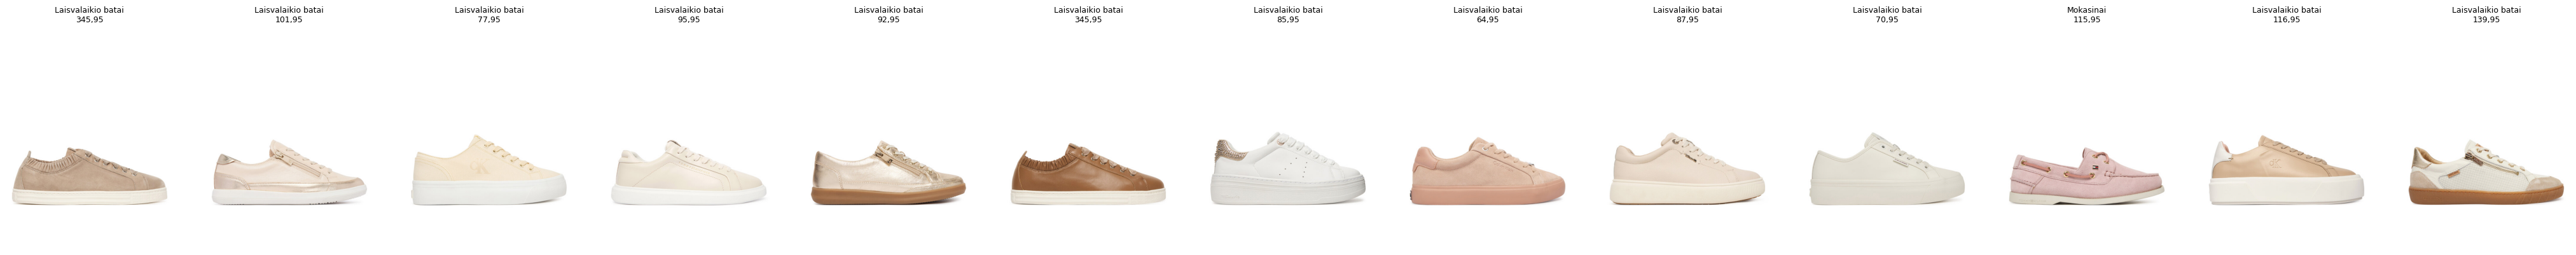

In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "ViT-B/32"

FEATURE_FILE = "/content/drive/MyDrive/clip_features_products/clip_features.npz"
CSV_FILE = "/content/products_with_subcategory.csv"
QUERY_IMAGE = "/content/169AI-MLC-051-1-797941_17.jpg"
TOP_N = 13 #Kiek vaizdų norima

# Leidžiame rinktis ar norima filtruoti pagal lytį
CATEGORY_FILTER = input("Įveskite 'Moterims', 'Vyrams' arba palikite tuščią: ").strip() or None

# Modelio paleidimas
model, preprocess = clip.load(MODEL_NAME, device=DEVICE)
model.eval()

# Turimų požymių paleidimas
data = np.load(FEATURE_FILE, allow_pickle=True)
image_paths = data["paths"]
features = data["features"]

# Susidaromas žodynas
products_dict = {}
with open(CSV_FILE, encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter=";")
    for row in reader:
        prod_id = str(row["ID"])
        products_dict[prod_id] = row

# Atfiltruojama pagal kategoriją
filtered_features = []
filtered_image_paths = []

for idx, path in enumerate(image_paths):
    prod_id = os.path.splitext(os.path.basename(path))[0]
    row = products_dict.get(prod_id, {})
    if CATEGORY_FILTER is None or row.get("Category") == CATEGORY_FILTER:
        filtered_features.append(features[idx])
        filtered_image_paths.append(path)

if not filtered_features:
    raise ValueError("Nėra produktų šiai kategorijai")

filtered_features = np.vstack(filtered_features)

# Apdorojamas vaizdas
image = Image.open(QUERY_IMAGE).convert("RGB")
image_input = preprocess(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    query_feature = model.encode_image(image_input)
    query_feature = query_feature / query_feature.norm(dim=-1, keepdim=True) # normavimas

query_feature = query_feature.cpu().numpy()

# Atliekama panašaus vaizdo paieška pagal vaizdą
nn = NearestNeighbors(n_neighbors=TOP_N, metric="cosine")
nn.fit(filtered_features)

distances, top_idx = nn.kneighbors(query_feature)

# Iš atstumų paverčiame į panašumus
similarities = 1 - distances[0]

# Šiuo atveju išspausdinami rezultatai teksto pavidalu
print(f"\nTop {TOP_N} similar products to {QUERY_IMAGE}:\n")
for rank, (idx, sim) in enumerate(zip(top_idx[0], similarities), start=1):
    filename = os.path.basename(filtered_image_paths[idx])
    prod_id = os.path.splitext(filename)[0]
    row = products_dict.get(prod_id, {})
    subcat = row.get("Subcategory", "Unknown")
    price = row.get("Price", "Unknown")
    category = row.get("Category", "Unknown")

    print(f"{rank}. {filename} | Category: {category} | Subcategory: {subcat} | Price: {price} | Similarity: {sim:.4f}")

# Vaizdų rezultatai
plt.figure(figsize=(4 * TOP_N, 5))
for i, idx in enumerate(top_idx[0]):
    img = Image.open(filtered_image_paths[idx]).convert("RGB")
    filename = os.path.basename(filtered_image_paths[idx])
    prod_id = os.path.splitext(filename)[0]
    row = products_dict.get(prod_id, {})
    subcat = row.get("Subcategory", "Unknown")
    price = row.get("Price", "Unknown")

    plt.subplot(1, TOP_N, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{subcat}\n{price}", fontsize=9)

plt.show()
